## D212 OFM4 Task 1: Clustering Techniques

Data Mining II - D212
<br> 
Clustering Techniques
<br> 
Instructor: Dr. Kesselly Kamara
<br> 
Student Name: Devon E. Johnson
<br> 
Student ID: 011494484
<br> 
Email: djo3593@wgu.edu
<br> 

### Table of Contents

* [A1: Research Question](#A1:-Research-Question)
* [A2: Analysis Goal](#A2:-Analysis-Goal)
* [B1: Clustering Technique](#B1:-Clustering-Technique)
* [B2: Assumption](#B2:-Assumption)
* [B3: Packages and Libraries](#B3:-Packages-and-Libraries)
* [C1: Data Pre-Processing Goal](#C1:-Data-Pre-Processing-Goal)
* [C2: Variables](#C2:-Variables)
* [C3: Data Preparation Process](#C3:-Data-Preparation-Process)
* [C4: Cleaned Data Set](#C4:-Cleaned-Data-Set)
* [D1: Optimal Clusters](#D1:-Optimal-Clusters)
* [D2: Clustering Code](#D2:-Clustering-Code)
* [E1: Cluster Quality](#E1:-Cluster-Quality)
* [E2: Results and Implications](#E2:-Results-and-Implications)
* [E3: Limitations](#E3:-Limitations)
* [E4: Recommended Course of Action](#E4:-Recommended-Course-of-Action)
* [F1: Panopto Presentation](#F1:-Panopto-Presentation)
* [G1: Code References](#G1:-Code-References)
* [H1: Source References](#H1:-Source-References)

### A1: Research Question

Hospital senior leadership has expressed a direct interest in better understanding their patient population to drive improvements in patient care. The dataset provided includes various Likert-type survey questions that evaluate each patient's perception of care quality on a scale from 1 (most satisfied) to 8 (least satisfied). Hierarchical clustering using Euclidean distance has been explored in real-world scenarios for analyzing Likert surveys, so I will endeavor to implement this approach here to evaluate the findings (Handorf et al., 2018).

### A2: Analysis Goal

The objective of this analysis is to identify whether a significant pattern of satisfaction exists among clusters of patients within the sample data. For example, if hierarchical clustering indicates shows distinct levels of satisfcation between groups, we can conduct additional analysis to assign identifying demographic traits from the original dataset to those groups. Uncovering which patients are more likely to be dissatisfied, e.g. older patients, patients with anxiety, patients with lower income, etc., can help the administration dig deeper into the underlying reasons why those demographics are linked to poorer satisfaction outcomes. This knowledge can help reveal the "why" behind low satisfaction scores and help develop targeted improvements (Bock, n.d.). 

### B1: Clustering Technique

I began this assignment by investigating the viability of using k-means with the available continuous variables in the medical dataset. In the process of considering the applicable variables and researching others' outcomes when applying clustering analysis to similar data, I discovered some scholarly articles that used clustering analysis to analyze Likert-type survey questions, treating ordinal responses as continuous. One such study specified the distance metric as Euclidean, so I also adopted the Ward linkage method, which uses this metric automatically (Handorf et al., 2018). Euclidean distance is the most straightforward metric used in hierarchical clustering and better fits the multidimensionality and uniformity of my data than Manhattan distance or Gowers distance.

I do not necessarily expect this strategy to yield distinct and reliable clusters. Still, it will help narrow my analytical options for successfully mining this section of the dataset for valuable insights. During my research, I encountered multiple analyst accounts indicating that the process can often be trial-and-error and should be adjusted as needed to yield the best results. My most optimistic expectation is that I will successfully split my patient population into distinct groups to which I can assign demographic or other unique traits that will help the hospital faculty to improve its overall satisfaction scores.

### B2: Assumption

One central assumption of hierarchical clustering is that the data should contain no significant outliers that could distort the process (SPSS Analysis, n.d.). I will examine the distribution of responses to each Likert survey question during my analysis to assess how well this method can be expected to perform with the data at hand. 

### B3: Packages and Libraries

**NumPy (Numerical Python):** A commonly used library with built-in mathematical functions that supports large matrices and multi-deminsional data. I will use this library throughout my code. 

**Pandas:** A library built on top of NumPy for data cleaning, transformation, and analysis.  I will use this library throughout my code. 

**Matplotlib:** A useful library for plotting numerical data and generating statistical visualizations ("Libraries in Python," 2024). I will use this library to generate visualizations showing the initial distribution of the survey responses as well as to generate silhouette plots for the initial cluster trials. I will also import the cm module to use Matplotlib’s built-in colormaps ("Choosing Colormaps in Matplotlib — Matplotlib 3.10.7 documentation," n.d.).

**Seaborn:** A library built on top of matplotlib for more advanced data visualization and exploration ("Introduction to Seaborn - Python," 2025). I will use seaborn to generate a heat map chart showing the average satisfaction scores between the two clusters. 

**SciPy (Scientific Python):** A library built on top of NumPy that can be used to generate high-level scientific computations. I will specifically import the stats module to calculate the initial distribution of the survey responses (The SciPy Community, n.d.).

**Scikit-learn:** This library works with NumPy and SciPy to support machine learning. I will specifically import the StandardScaler function from the pre-processing package of the library to standardize the data around a mean of zero and a standard deviation of 1 ("StandardScaler, MinMaxScaler and RobustScaler techniques - ML," 2025). Additionally, I will import the silhouette_score and silhouette_samples functions from the metrics package, and the AgglomerativeClustering function from the cluster package, to calculate and visualize potential cluster sizes for my data sample (SK, 2019). Later in the analysis, I will use the hierarchy module of the cluster package to import the linkage, fcluster, and dendrogram functions to execute my clustering analysis and visualize the results ("Hierarchical clustering in machine learning," 2025).


### C1: Data Pre-Processing Goal

I will first prepare my data by reducing it to the variables applicable to this portion of the analysis —the numbered "items" at the tail end of the dataset. I will rename these variables to reflect the Likert survey questions they represent. 

However, this does not represent my primary data pre-processing goal, which is reversing the score ranking system currently displayed in the data. Currently, the survey questions are unorthodox in that the lower number (1) represents a more positive experience while the higher number (8) represents a less positive experience. While this may have suited the initial goals of the survey, it will inherently confuse the analysis, so I will reverse the ranking so that lower numbers indicate lower satisfaction and higher numbers indicate higher satisfaction ("Reverse coding in survey design," 2025). 

Simultaneously, I will convert the current datatypes of the survey questions to float64 so they align with the continuous datatype best suited for hierarchical clustering analysis (Kelta, 2023). 

In [1]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D212\medical_clean.csv'
df = pd.read_csv(file_path, index_col = 0)

#Code for Fixing Naming Conventions/Missleading Labels
df.rename(columns={"Item1" : "likert_timely_admission", "Item2" : "likert_timely_treatment", "Item3" : "likert_timely_visit", "Item4" : "likert_reliablity", "Item5" : "likert_options", "Item6" : "likert_treatment_hrs", "Item7" : "likert_courteous_staff", "Item8" : "likert_dr_active_listening"}, inplace = True)  

#Reduced dataset with relevant variables for clustering analysis
likert_df = df[["likert_timely_admission", "likert_timely_treatment", "likert_timely_visit", "likert_reliablity", "likert_options", "likert_treatment_hrs", "likert_courteous_staff", "likert_dr_active_listening"]].copy()
likert_df.head(5)

,likert_timely_admission,likert_timely_treatment,likert_timely_visit,likert_reliablity,likert_options,likert_treatment_hrs,likert_courteous_staff,likert_dr_active_listening
CaseOrder,,,,,,,,
1,3,3,2,2,4,3,3,4
2,3,4,3,4,4,4,3,3
3,2,4,4,4,3,4,3,3
4,3,5,5,3,4,5,5,5
5,2,1,3,3,5,3,4,3


In [2]:
#Establish reverse rating where higher numbers indicate positive experiences and lower numbers indicate poor experiences
reverse_rating = {1: 8, 2: 7, 3: 6, 4: 5, 5: 4, 6: 3, 7: 2, 8: 1}

# List of all likert columns
likert_columns = ["likert_timely_admission", "likert_timely_treatment", "likert_timely_visit", "likert_reliablity", "likert_options", "likert_treatment_hrs",  "likert_courteous_staff", "likert_dr_active_listening"]

# Apply mapping and convert to float for all columns
for col in likert_columns:
    likert_df[col] = likert_df[col].map(reverse_rating).astype("float64")

#Check outcomes
likert_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   likert_timely_admission     10000 non-null  float64
 1   likert_timely_treatment     10000 non-null  float64
 2   likert_timely_visit         10000 non-null  float64
 3   likert_reliablity           10000 non-null  float64
 4   likert_options              10000 non-null  float64
 5   likert_treatment_hrs        10000 non-null  float64
 6   likert_courteous_staff      10000 non-null  float64
 7   likert_dr_active_listening  10000 non-null  float64
dtypes: float64(8)
memory usage: 703.1 KB


### C2: Variables

Utilized variables:

 1.   likert_timely_admission - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 3.   likert_timely_treatment - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 4.   likert_timely_visit - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 5.   likert_reliablity - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 6.   likert_options - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 7.   likert_treatment_hrs - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 8.   likert_courteous_staff - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 
 9.   likert_dr_active_listening - converted from int64 to float64. The variable is technically ordinal but we will treat it as continuous for the purposes of hierarchical clustering. 

### C3: Data Preparation Process

I first generated quantile-quantile and histogram plots for each Likert survey question to examine the distribution of responses. This helped me predict how well hierarchical clustering would perform on my selected data and anticipate any potential quality issues.

The resulting histogram plots indicated approximately normal distributions centered around 5-6 across the eight questions. Still, the Q-Q plots showed consistent deviation from normality in the upper right tail, indicating the presence of outliers at the high end of the satisfaction scale. This showed that more patients gave extremely high ratings than would be expected in a normal distribution ("Python data skills 8: Data visualization," 2023).

Hierarchical clustering with Ward's method using Euclidean distance is sensitive to outliers and variables with different scales, as they can disproportionately influence distance calculations. To prevent variables with more variance from dominating the clusters, I applied StandardScaler to center each variable around a mean of 0 and scale it by a standard deviation of 1 ("StandardScaler, MinMaxScaler and RobustScaler techniques - ML," 2025).

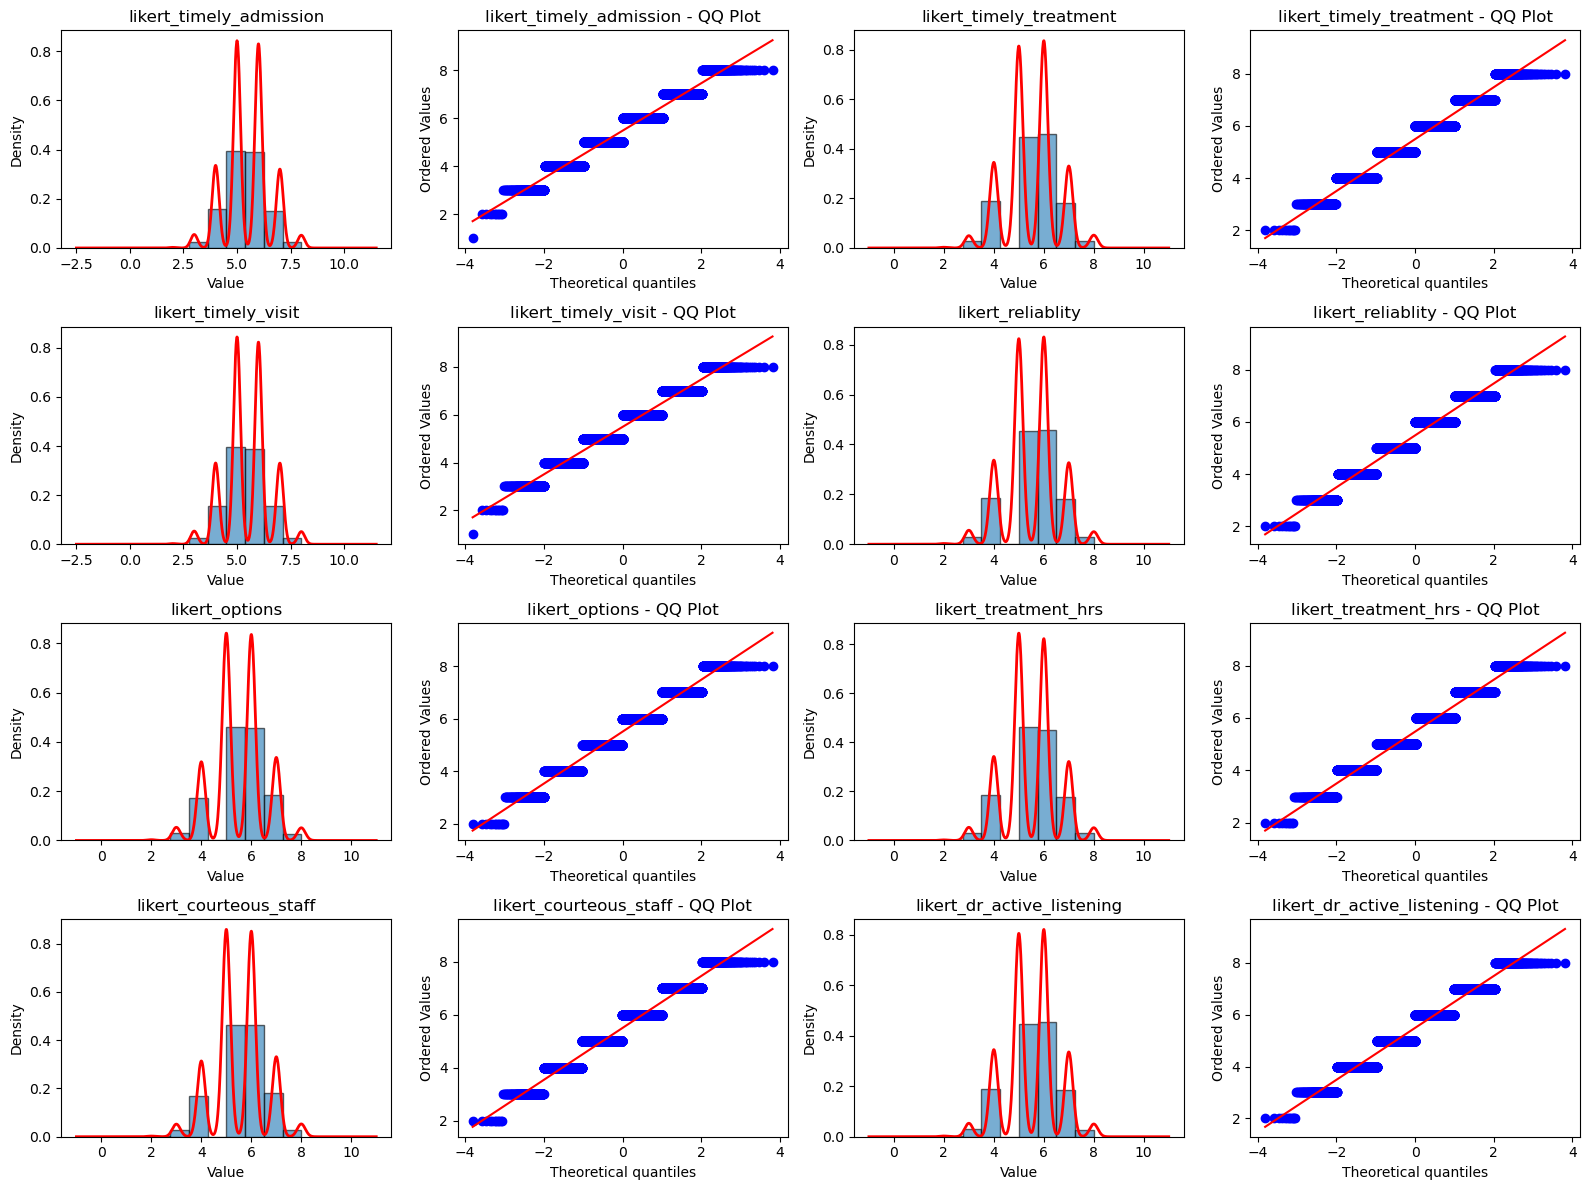

In [3]:
#Import necessary libraries, packages, and modules
import matplotlib.pyplot as plt
from scipy import stats

# Create subplots for all likert columns
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(likert_columns):
    # Generate Quantile Quantile (QQ) Plot
    stats.probplot(likert_df[col].dropna(), dist="norm", plot=axes[i*2+1])
    axes[i*2+1].set_title(f'{col} - QQ Plot')
    #Generate histogram plots
    axes[i*2].hist(likert_df[col].dropna(), bins=8, density=True, alpha=0.6, edgecolor='black')
    likert_df[col].dropna().plot(kind='density', ax=axes[i*2], color='red', linewidth=2)
    axes[i*2].set_title(f'{col}')
    axes[i*2].set_xlabel('Value')
    axes[i*2].set_ylabel('Density')

#Generate charts
plt.tight_layout()
plt.show()

In [4]:
#Import StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

#Use the StandardScaler function to 
scaler = StandardScaler()
likert_scaled_df = pd.DataFrame(scaler.fit_transform(likert_df), columns=likert_df.columns, index=likert_df.index)
likert_scaled_df.head(5)

,likert_timely_admission,likert_timely_treatment,likert_timely_visit,likert_reliablity,likert_options,likert_treatment_hrs,likert_courteous_staff,likert_dr_active_listening
CaseOrder,,,,,,,,
1,0.502755,0.489673,1.463247,1.462128,-0.488380,0.506139,0.483672,-0.470420
2,0.502755,-0.476723,0.494914,-0.467946,-0.488380,-0.462548,0.483672,0.489033
3,1.471828,-0.476723,-0.473418,-0.467946,0.482361,-0.462548,0.483672,0.489033
4,0.502755,-1.443118,-1.441750,0.497091,-0.488380,-1.431236,-1.474513,-1.429874
5,1.471828,2.422464,0.494914,0.497091,-1.459121,0.506139,-0.495421,0.489033


### C4: Cleaned Data Set

In [5]:
# Save dataset to CSV, ignore index (if included, this will create an additional unnecessary column)
likert_scaled_df.to_csv('likert_scaled.csv', index=False)
likert_scaled_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   likert_timely_admission     10000 non-null  float64
 1   likert_timely_treatment     10000 non-null  float64
 2   likert_timely_visit         10000 non-null  float64
 3   likert_reliablity           10000 non-null  float64
 4   likert_options              10000 non-null  float64
 5   likert_treatment_hrs        10000 non-null  float64
 6   likert_courteous_staff      10000 non-null  float64
 7   likert_dr_active_listening  10000 non-null  float64
dtypes: float64(8)
memory usage: 703.1 KB


### D1: Optimal Clusters

I adapted code from Kaggle to determine the optimal cluster size for my data sample, using the silhouette score as my chosen metric (SK, 2019). I chose the silhouette algorithm over the elbow method because it is generally more accurate and and is better able to deal with overlapping clusters. The elbow method works best with low-dimensional, well-separated clusters, which I could not assume for Likert scale survey data. The silhouette score measures how similar each data point is to its own cluster compared to other clusters and ranges from -1 to 1, with higher values indicating better-defined clusters ("Elbow method vs. silhouette score: Which is better?," 2025).

I calculated the average silhouette scores and generated corresponding silhouette plots for nine different cluster sizes, ranging from two to ten. In the end, two clusters was associated with the highest silhouette score of 0.164, but even this value was relatively low compared to the optimal value of 1. This modest result was reflected in the associated cluster visualization, which showed little separation between the two clusters. 

The weak silhouette scores across all cluster sizes suggest that hierarchical clustering may not be the most appropriate method for this data. However, completing the full analysis may still offer useful insights and should at minimum help me tailor a more effective approach for mining the Likert survey questions in the future. Given that my initial research for this assignment encouraged a trial-and-error approach to clustering analysis, this will not constitute wasted effort. As such, I continued with the hierarchical clustering approach and opted for two clusters for my analysis, as they provided the best fit based on the calculated silhouette score.

For n_clusters = 2 The average silhouette_score is : 0.1635947738353465
For n_clusters = 3 The average silhouette_score is : 0.1187689197689012
For n_clusters = 4 The average silhouette_score is : 0.0805649729971612
For n_clusters = 5 The average silhouette_score is : 0.07620097321376236
For n_clusters = 6 The average silhouette_score is : 0.05238876342502621
For n_clusters = 7 The average silhouette_score is : 0.04100088232533161
For n_clusters = 8 The average silhouette_score is : 0.036842919224217736
For n_clusters = 9 The average silhouette_score is : 0.03846480036050449
For n_clusters = 10 The average silhouette_score is : 0.03596875360799855


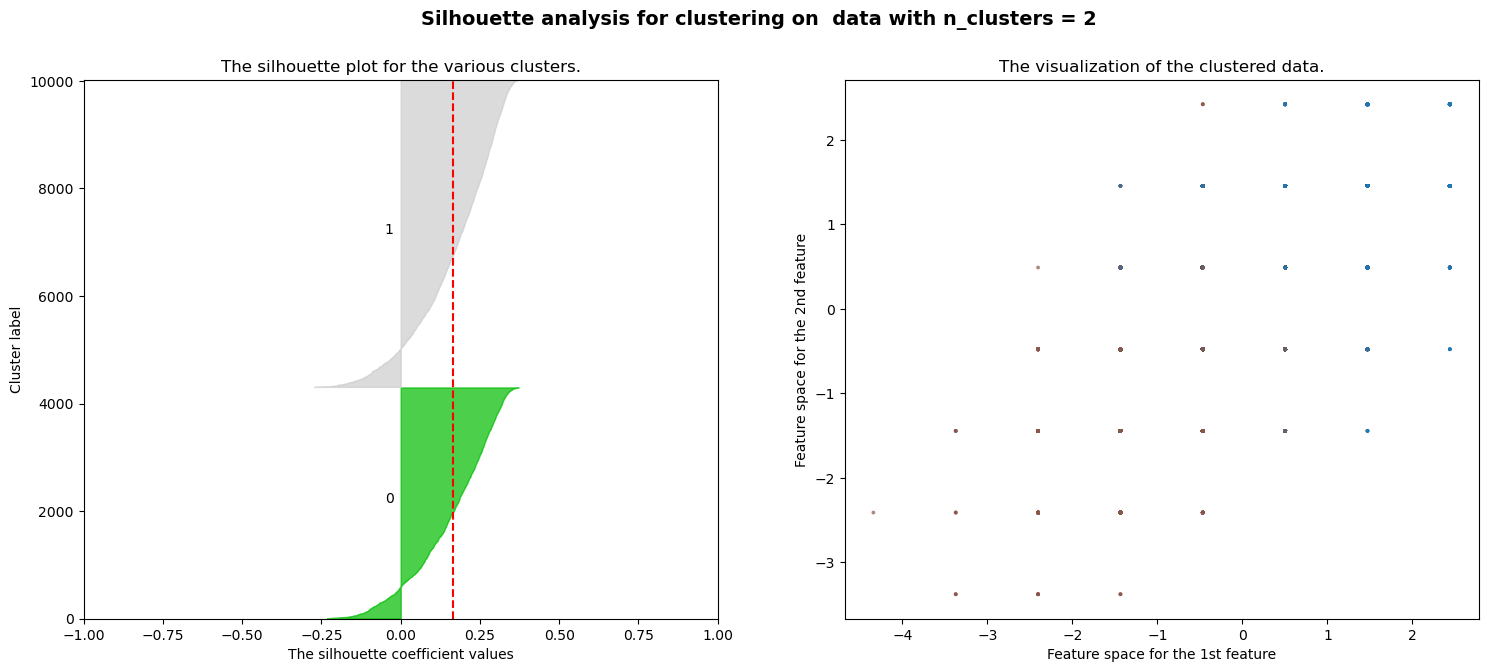

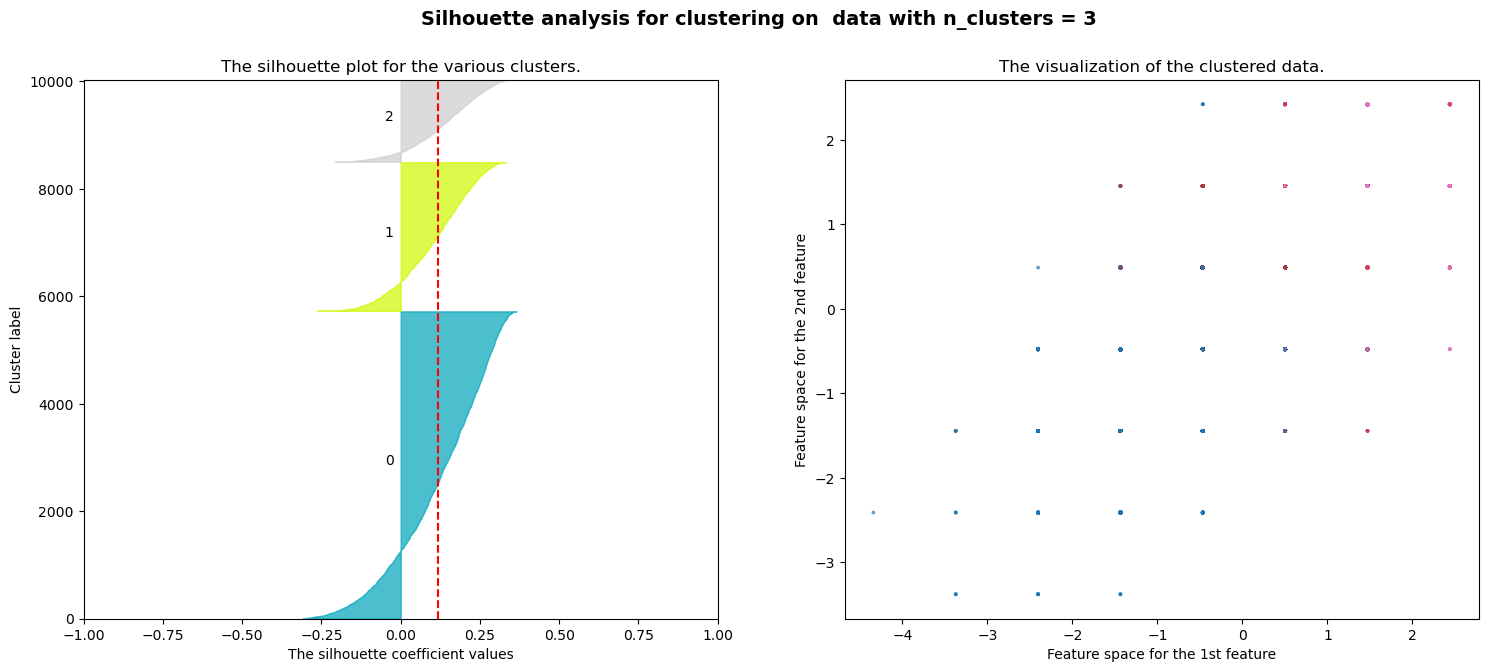

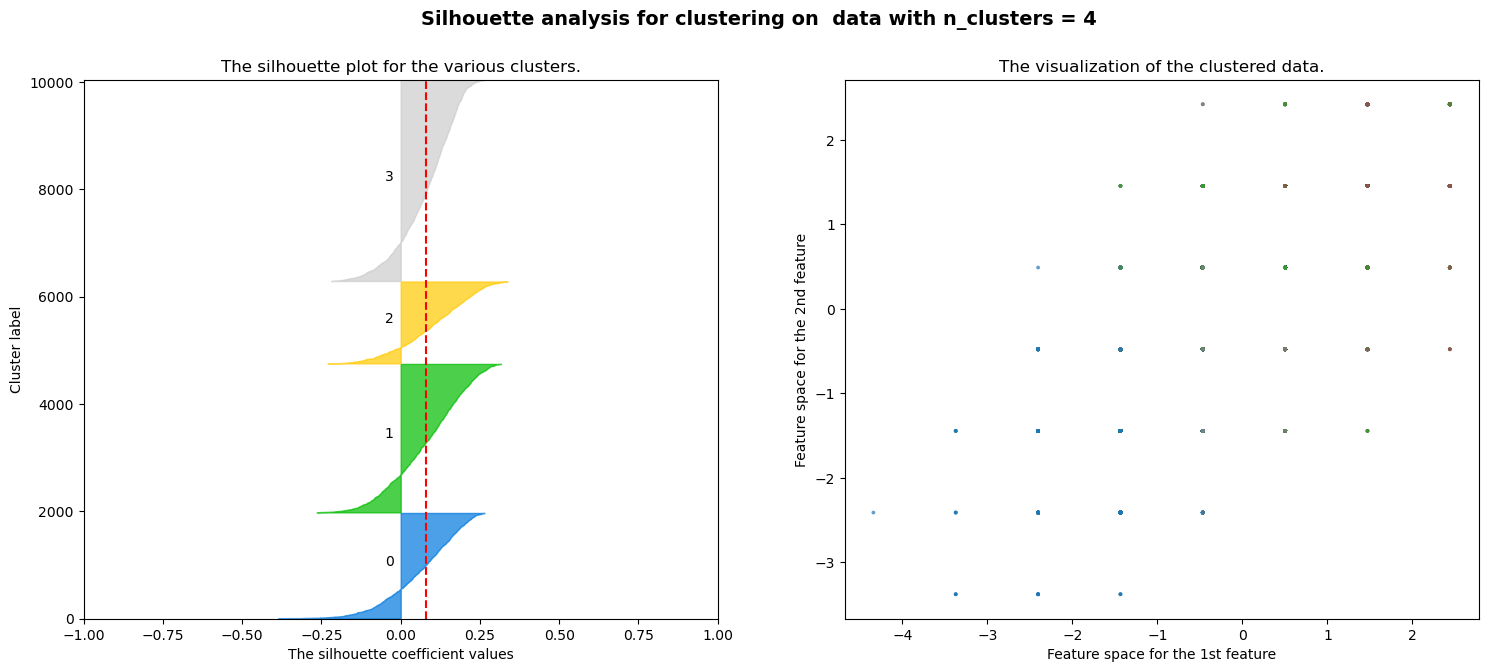

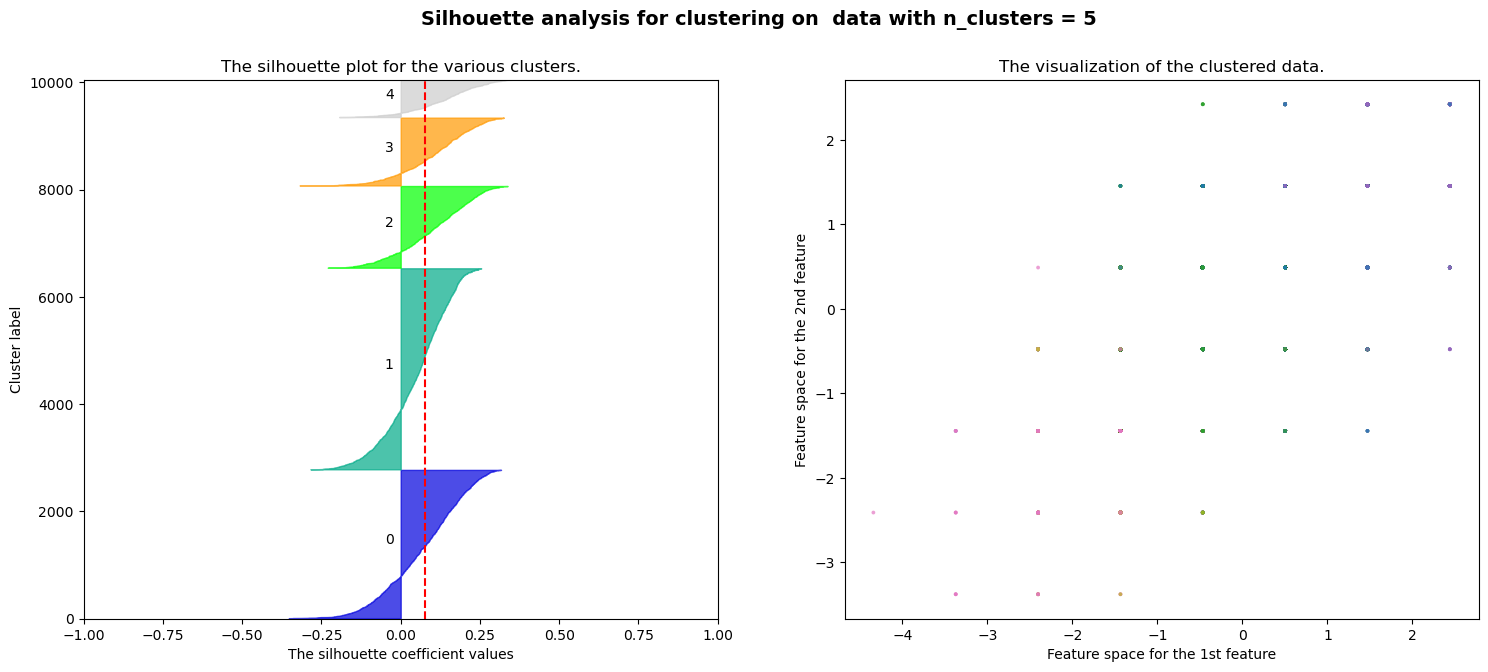

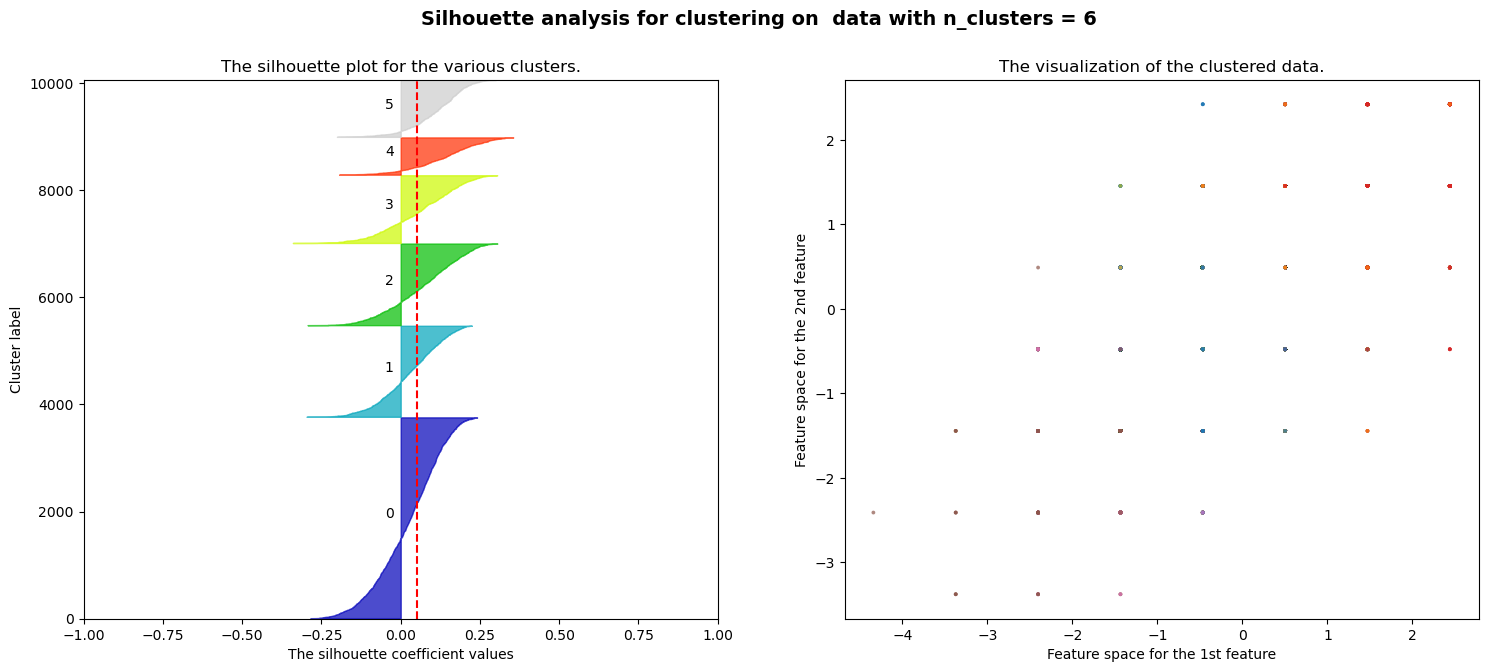

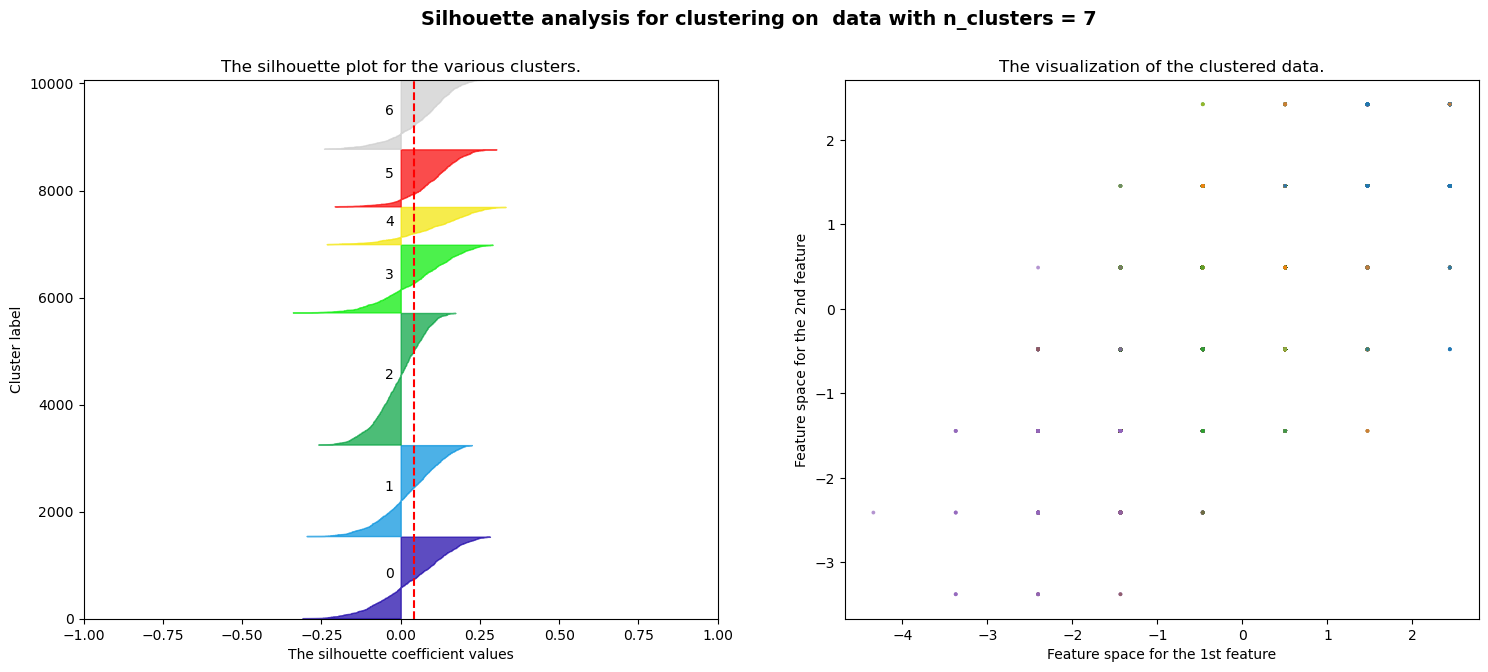

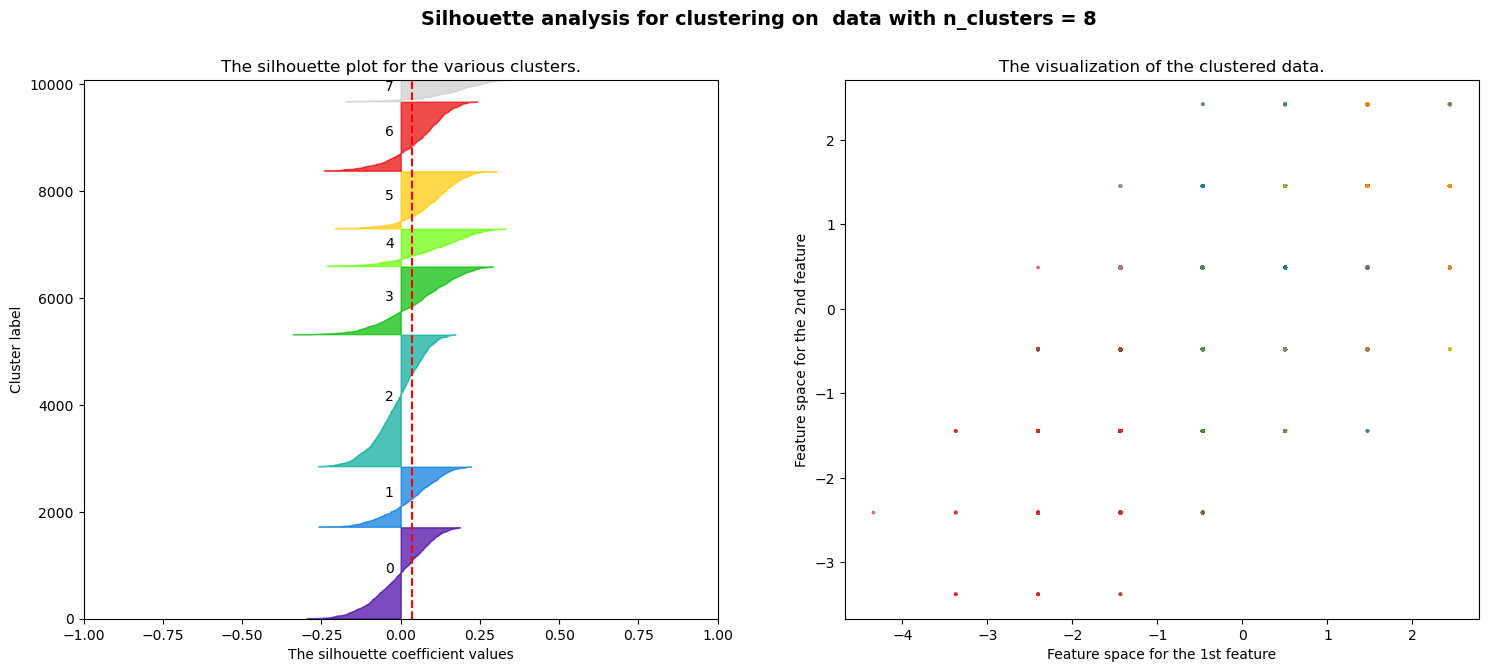

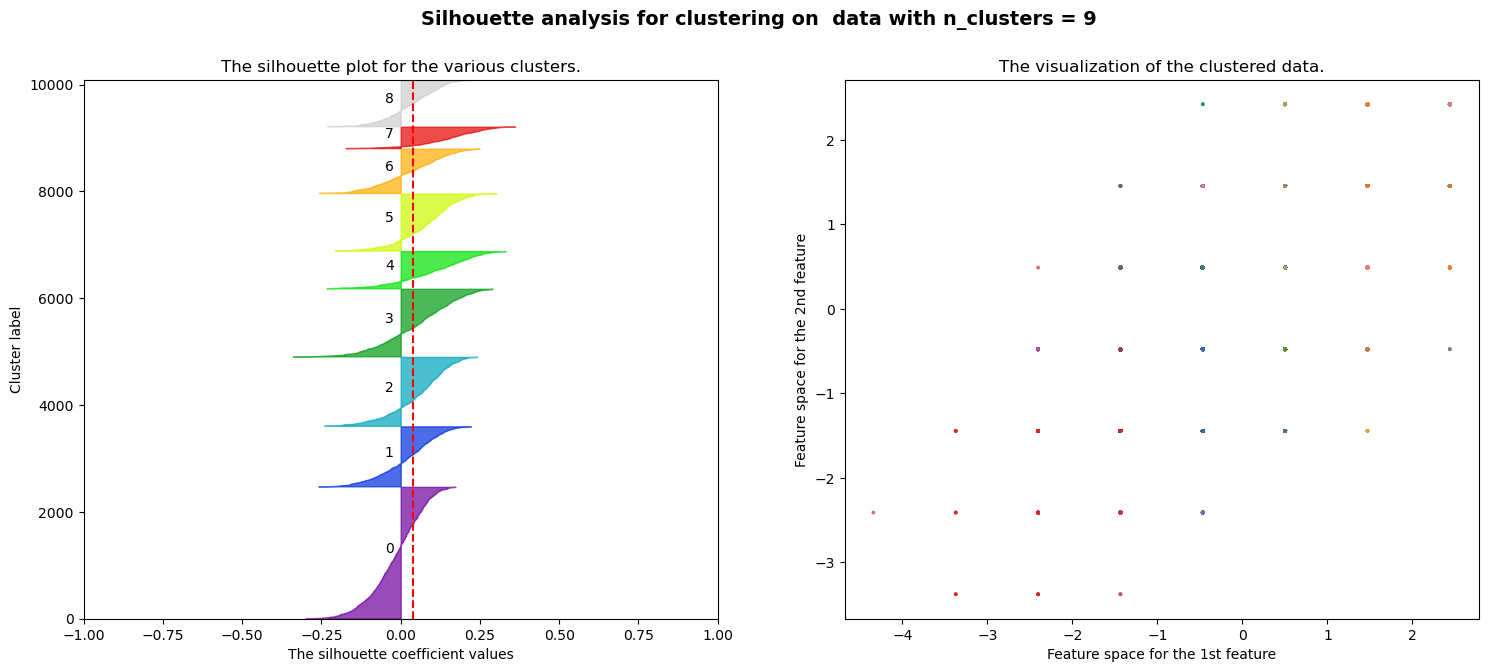

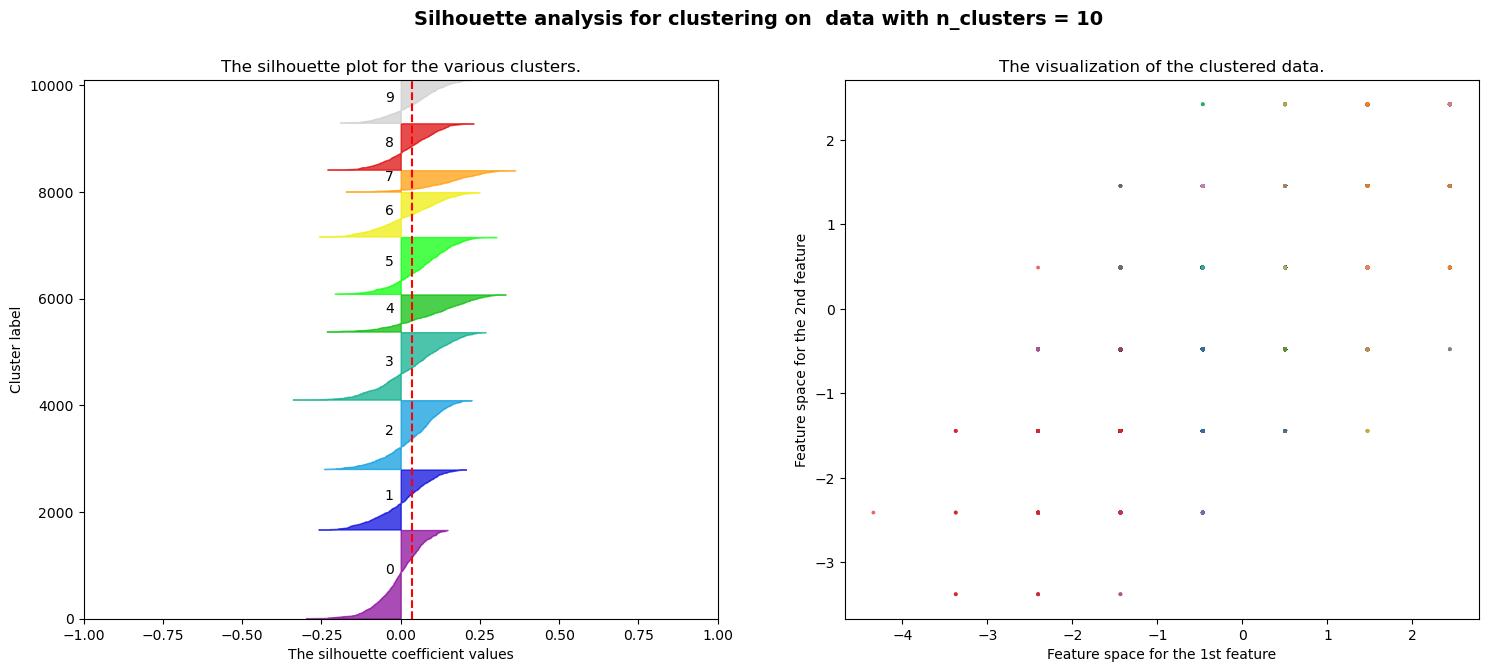

In [6]:
#Import necessary modules and functions
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.cm as cm

#Assign X for simplicity
X = likert_scaled_df.values

for n_clusters in range(2,11):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)
    # Set silhouette coefficient
    ax1.set_xlim([-1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters) * 10])
    # Initialize the clusterer with n_clusters value and a random generator seed of 10 for reproducibility.
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    cluster_labels = clusterer.fit_predict(X)
    #The silhouette_score gives the average value for all the samples. This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i+1) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  
        
    #Set chart and axes titles
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Second plot showing the actual clusters formed
    colors = cm.tab10(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    #Set chart and axes titles
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for clustering on  data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

### D2: Clustering Code

I adapted code from Geeks for Geeks to implement hierarchical agglomerative clustering, generating a scatter plot to show the cluster assignments projected onto the first two features and a dendrogram to visualize the hierarchical merging process with all eight Likert questions simultaneously, with the y-axis representing the Euclidean distance at which the clusters were merged and the x-axis showing the arrangement of individual patients ("Hierarchical clustering in machine learning," 2025).

ward_cluster_labels
0    4290
1    5710
Name: count, dtype: int64


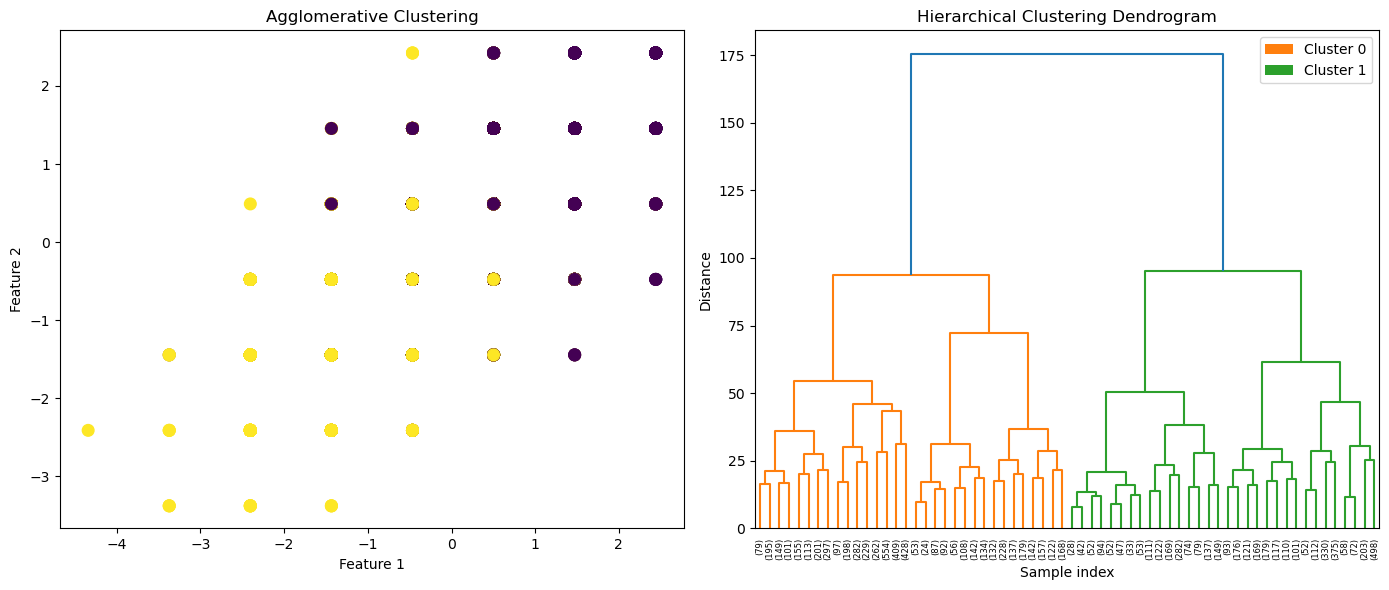

In [7]:
#Import necessary functions
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from matplotlib.patches import Patch

#Establish clustering method with two clusters and ward linkage (Ward's method uses Euclidean distance by default)
clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = clustering.fit_predict(X)
agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
agg.fit(X)
df['ward_cluster_labels'] = clustering.fit_predict(likert_scaled_df)
print(df['ward_cluster_labels'].value_counts().sort_index())

#Plot dendrogram
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

#Establish plot sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Plot design and titles for Agglomerative Clustering
ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

#Plot design and titles for hierarchical clustering
plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

# Add legend to dendrogram
legend_elements = [Patch(facecolor='C1', label='Cluster 0'),
                   Patch(facecolor='C2', label='Cluster 1')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

### E1: Cluster Quality

The earlier calculated silhouette score of 0.164 was very low, which led me to set my initial expectations for poor cluster quality. This expectation seemed supported by the scatter plot, which showed little to no separation between the two groups when projected onto the first two features. However, the hierarchical clustering dendrogram challenged these low expectations, as the two main clusters merged at a notably higher distance than the internal clusters, which indicated a moderate degree of separation at the highest hierarchical level. The hierarchical dendrogram showed that the clusters were not strongly distinct in lower-dimensional projections, which explained the low degree of separation in the scatter plot and the weak silhouette score, but could reveal meaningful differences when all eight survey questions were considered together. 

### E2: Results and Implications

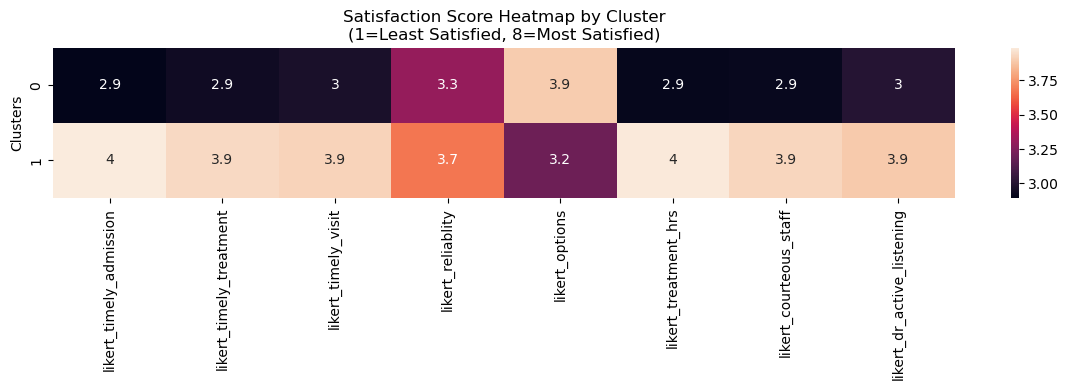

In [8]:
import seaborn as sns

#Calculate average of each likert survey response for each cluster
cluster_satisfaction = df.groupby('ward_cluster_labels')[likert_scaled_df.columns].mean()

#Generate heatmap visualization
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cluster_satisfaction, annot=True)
ax.set_ylabel("Clusters")
plt.title('Satisfaction Score Heatmap by Cluster\n(1=Least Satisfied, 8=Most Satisfied)')
plt.tight_layout()
plt.show()

In order to better understand the practical relevance of my results and truly understand the quality of this cluster analysis, I decided to generate a heatmap with average satisfaction scores for each survey question across the two groups. I found this method to be very insightful, as it immediately showed that the groups were not evenly cleaved in terms of satisfaction - or, at least, did not form one distinctly satisfied group and one dissatisfied group. The first cluster was generally more dissatisfied across the survey, but was more satisfied regarding treatment options. While the second cluster was generally more satisfied, all average satisfaction scores were still fairly low, with no average score higher than 4, indicating that the quality of patient care would benefit from sweeping improvements rather than targeted ones. 

Still, it might be beneficial to link the patient IDs grouped in Cluster 0 to see what is driving their low satisfaction ratings. While the solution here doesn't seem to point to developing targeted interventions, it is likely that many of the issues Cluster 0 is experiencing are also impacting Cluster 1, though to a lesser extent, and addressing those concerns might help lift overall satisfaction in both groups. One downside of Likert surveys is that they don't offer much context beyond simply showing positive or negative experiences as a broad spectrum, so reaching out to these patients for more specific feedback could help the hospital better understand how it can improve. 

### E3: Limitations

There are two significant limitations to the analysis: the underlying data and the selected mining method. First, the data itself presents an issue as dissatisfied patients disproportionately comprise the sample across all survey questions. This inherently contradicts the benefit of applying hierarchical clustering to identify distinct clusters of dissatisfied and satisfied patients, as **all** patients are dissatisfied to some extent. 

Additionally, hierarchical clustering may not be the best method for analyzing Likert-style survey questions, as the data is generally treated as ordinal, and treating it as continuous presents issues that are commonly debated in data science. Using Euclidean distance on ordinal Likert data assumes equal intervals between points, which may not actually be the case. For example, a patient may not perceive the same psychological difference between a 6 and a 5 or a 3 and a 2 on the satisfaction scale (Wermelink, 2022).

### E4: Recommended Course of Action

There are two general courses of action I see here—one focused on continuing to mine the current data with other analytic approaches —and the other on using what we have already discovered to gather more information to better understand the root causes of patient dissatisfaction.

If the administration prefers to continue mining the current data for additional insights, I recommend attempting density-based spatial clustering (DBSCAN). Compared to hierarchical clustering, DBSCAN is better equipped to handle outliers and the careless responses that often skew Likert-style survey results. Especially given the current survey model's reverse-scaling method, which may prompt some respondents to mistakenly select the wrong options, DBSCAN may yield higher-quality results than the current hierarchical clustering model. Additionally, DBSCAN has been shown to perform better as the number of items and the size of the items increase. As we have eight survey questions with possible responses ranging from 1 to 8, which is comparatively wide compared to the standard Likert range of 1 to 5, DBSCAN may outperform hierarchical clustering. A 2022 master's thesis by Henk-Jan Wermelink, published by Erasmus University Rotterdam, examined the performance of DBSCAN in analyzing Likert-style questions under similar conditions and demonstrated promising results, though it remained unclear whether it was ultimately superior to k-means clustering (Wermelink, 2022). From an analytical perspective, it would be interesting to apply DBSCAN here, and it may yield higher-quality results. 

That said, the ultimate benefit of continuing the clustering analysis on this data seems questionable, given that it's evident we don't even have a satisfied group of patients to compare against. The most reasonable course of action is to obtain more specific feedback from these dissatisfied patients to inform broad hospital improvements. The hospital administration could garner more specific input from the dissatisfied sample in a variety of ways:

**Follow-Up Survey with Dissatisfied Clusters:**
Develop an A/B survey that suggests potential changes in the hospital administration and care procedures, and release this to the existing patient pool so they can choose what improvements they would most like to see, primarily referencing Cluster 0 and sampling patients who identified as dissatisfied with treatment options from Cluster 1 (since this is the only section in which Cluster 0 outperformed Cluster 1). Incorporate a section at the end that allows patients to provide free-form feedback they couldn't otherwise capture in the multiple-choice questions. Offer a small gift card or other reward in exchange for their time and effort.

*Pros:* Relatively low effort and intensity on the front end, and adds more depth to the current survey data. 

*Cons:* Potentially expensive and more intensive on the back end as far as data analysis

**Qualitative Investigation with Focus Groups:**
Reach out to the existing dissatisfied patient pool to participate in focus groups. Offer a small gift card or other reward in exchange for their time and consideration, and, among patients who agree to participate, sample about 15-20 individuals with demographically diverse traits from each category to conduct semi-structured interviews aimed at identifying the major issues with the care provided. 

*Pros:* Offers substantially more insight than the Likert survey scale and direct engagement with the patients.

*Cons:* High-effort and time-intensive, potentially expensive, and samples only a small portion of the overall patient population, so may not yield a sufficient return on investment. Additionally, if demographic diversity is not maintained—which may be challenging to begin with, given a sample of only 15-20 individuals per group—this may lead to a skewed result that addresses only the concerns of one patient subgroup, leaving the rest still dissatisfied.

**Adjust the Current Survey:**
Incorporate qualitative sections following each Likert-scaled question to garner more specific feedback from patients to identify the issues experienced, as well as the features that they liked and wish to see more of.

*Pros:* Builds on the current process and should be relatively inexpensive and low-effort on the front end

*Cons:* Since this requires significant changes to the survey style and data collection procedures, it will take additional time and may not yield actionable data for months. Additionally, this method may result in survey fatigue, which may already be an issue present in the current system. Developing an efficient method for reviewing these qualitative responses on the back end will be more complex and intensive. Still, the hospital may incorporate natural language processing (NLP) or topic modeling to rapidly sift through the feedback and identify recurring trends.

### F1: Panopto Presentation

My panopto presentation may be viewed at the following link: 

https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=0b0376e8-4dc1-4890-be29-b38201552655

### G1: Code References

Choosing Colormaps in Matplotlib — Matplotlib 3.10.7 documentation. (n.d.). Matplotlib — Visualization with Python. https://matplotlib.org/stable/users/explain/colors/colormaps.html

Hierarchical clustering in machine learning. (2025, September 12). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/hierarchical-clustering/

Kelta, Z. (2023, January 19). An introduction to hierarchical clustering in python. DataCamp. https://www.datacamp.com/tutorial/introduction-hierarchical-clustering-python

Scikit-learn developers. (n.d.). 6.3. Preprocessing data. scikit-learn. Retrieved March 11, 2025, from https://scikit-learn.org/stable/modules/preprocessing.html

SK, K. (2019, November 15). Hierarchical clustering. Kaggle: Your Machine Learning and Data Science Community. https://www.kaggle.com/code/kevzzsk/hierarchical-clustering

Sklearn.model_selection.train_test_split. (n.d.). scikit-learn. Retrieved March 30, 2025, from https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

SPSS Analysis. (n.d.). Hierarchical cluster analysis. https://spssanalysis.com/hierarchical-cluster-analysis-in-spss/

StandardScaler, MinMaxScaler and RobustScaler techniques - ML. (2025, July 12). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/

The pandas development team. (2024). Categorical data — pandas 2.2.2 documentation. pandas - Python Data Analysis Library. https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html

The SciPy Community. (n.d.). Pearsonr — SciPy v1.14.1 manual. Numpy and Scipy Documentation — Numpy and Scipy documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html


### H1: Source References

Bock, T. (n.d.). What is hierarchical clustering? DisplayR. https://www.displayr.com/what-is-hierarchical-clustering/

Elbow method vs. silhouette score: Which is better? (2025, July 5). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-vs-silhouette-score-which-is-better/

Handorf, E. A., Heckman, C. J., Darlow, S., Slifker, M., & Ritterband, L. (2018). A hierarchical clustering approach to identify repeated enrollments in web survey data. PLOS ONE, 13(9). https://doi.org/10.1371/journal.pone.0204394

Introduction to Seaborn - Python. (2025, October 3). GeeksforGeeks. https://www.geeksforgeeks.org/python/introduction-to-seaborn-python/

Libraries in Python. (2024, August 1). GeeksforGeeks. https://www.geeksforgeeks.org/python/libraries-in-python/

Reverse coding in survey design. (2025, September 11). The Patient Experience Platform | InsiderCX. https://www.insidercx.com/knowledge-base-article/reverse-coding-in-survey-design

Reverse coding in survey design. (2025, September 11). The Patient Experience Platform | InsiderCX. https://www.insidercx.com/knowledge-base-article/reverse-coding-in-survey-design

Wermelink, H. J. (2022). Robust clustering of rating scale data using DBSCAN [Master's thesis]. https://thesis.eur.nl/pub/62101/Final_MasterThesis_Henk_JanWermelink.pdf
